# Cassava Leaf Disease Classification 과제용 노트북

이 노트북은 Cassava Leaf Disease Classification 대회를 위한 제출용 노트북입니다.

- 카사바 잎 이미지를 이용한 다중 클래스 이미지 분류 문제를 수행합니다.
- 클래스 불균형을 확인하고, 학습/검증 데이터를 분리합니다.
- Baseline 성격의 CNN 계열 모델과 EfficientNet-B0 기반 모델을 사용합니다.
- Data augmentation, label smoothing, scheduler, TTA 등을 활용하여 성능 개선을 시도합니다.
- Validation Accuracy, Macro F1, Confusion Matrix, 오분류 사례를 분석합니다.


In [1]:
# 0. 기본 설정
#    - 필요한 라이브러리 import, random seed 고정, 실행 장치(device) 설정

import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.models import efficientnet_b0

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score

print('torch:', torch.__version__)
print('torchvision:', torchvision.__version__)


torch: 2.10.0+cu128
torchvision: 0.25.0+cu128


## 1. 기본 설정

Kaggle Notebook에서는 대회 데이터가 `/kaggle/input/...` 경로에 연결됩니다.  
본 노트북에서는 데이터 경로, 학습 파라미터, random seed 등을 한 곳에서 관리합니다.



In [2]:
# 1. 데이터 경로 및 하이퍼파라미터 설정
#    - Kaggle 대회 데이터 경로, 이미지 크기, batch size, epoch 등 학습 설정 정의

DATA_DIR = Path('/kaggle/input/competitions/cassava-leaf-disease-classification')

TRAIN_CSV = DATA_DIR / 'train.csv'
SAMPLE_SUBMISSION = DATA_DIR / 'sample_submission.csv'
TRAIN_IMG_DIR = DATA_DIR / 'train_images'
TEST_IMG_DIR = DATA_DIR / 'test_images'
LABEL_MAP_PATH = DATA_DIR / 'label_num_to_disease_map.json'

OUTPUT_PATH = Path('/kaggle/working/submission.csv')
BEST_MODEL_PATH = Path('/kaggle/working/best_v1_safe_model.pt')

SEED = 42

IMG_SIZE = 256
BATCH_SIZE = 32
EPOCHS = 5
LR = 1e-4
NUM_CLASSES = 5
LABEL_SMOOTHING = 0.05

MAX_TRAIN_SAMPLES = 6000

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)


Device: cuda


## 2. 데이터 로드

Cassava Leaf Disease Classification은 카사바 잎 이미지를 보고 5개 클래스 중 하나로 분류하는 컴퓨터비전 이미지 분류 문제입니다.  
먼저 학습 데이터, sample submission, label map을 불러와 데이터 구조를 확인합니다.



In [3]:
# 2. 데이터 로드
#    - train.csv, sample_submission.csv, label_num_to_disease_map.json을 불러와 데이터 구조 확인

train_df = pd.read_csv(TRAIN_CSV)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION)

print('train shape:', train_df.shape)
print('sample_submission shape:', sample_submission.shape)
display(train_df.head())
display(sample_submission.head())

if LABEL_MAP_PATH.exists():
    with open(LABEL_MAP_PATH, 'r') as f:
        label_map = json.load(f)
    print(label_map)
else:
    label_map = {str(i): str(i) for i in range(NUM_CLASSES)}

train shape: (21397, 2)
sample_submission shape: (1, 2)


,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3


,image_id,label
0,2216849948.jpg,4


{'0': 'Cassava Bacterial Blight (CBB)', '1': 'Cassava Brown Streak Disease (CBSD)', '2': 'Cassava Green Mottle (CGM)', '3': 'Cassava Mosaic Disease (CMD)', '4': 'Healthy'}


## 3. 클래스 불균형 확인

이미지 분류 문제에서는 클래스별 데이터 수 차이가 모델 성능에 영향을 줄 수 있습니다.  
따라서 학습 전에 각 클래스의 샘플 수를 확인하여 class imbalance 여부를 분석합니다.



label
0     1087
1     2189
2     2386
3    13158
4     2577
Name: count, dtype: int64


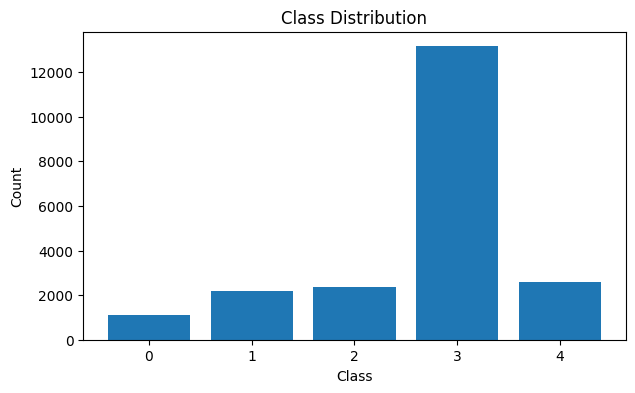

In [4]:
# 3. 클래스 불균형 확인
#    - 클래스별 이미지 개수를 확인하고 class imbalance 여부를 시각화

class_counts = train_df['label'].value_counts().sort_index()
print(class_counts)

plt.figure(figsize=(7, 4))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

## 4. Dataset 및 Transform 정의

학습 데이터에는 일반화 성능 향상을 위해 간단한 data augmentation을 적용합니다.  
검증 및 테스트 데이터에는 resize와 normalization만 적용하여 평가 과정이 안정적으로 이루어지도록 구성합니다.

이번 실험에서는 V1 성능을 기준으로 과도한 augmentation은 제외하고, 비교적 안전한 변환만 사용합니다.

- Resize
- RandomHorizontalFlip
- RandomRotation
- 약한 ColorJitter
- Normalization



In [5]:
# 4. Dataset 및 Transform 정의
#    - 이미지 전처리, augmentation, PyTorch Dataset 클래스를 정의

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.08, contrast=0.08, saturation=0.08),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

valid_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

# TTA용 transform입니다. test/validation 이미지를 좌우 반전하여 한 번 더 예측합니다.
tta_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

class CassavaDataset(Dataset):
    def __init__(self, df, image_dir, transform=None, is_test=False):
        self.df = df.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = self.image_dir / row['image_id']
        image = Image.open(image_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        if self.is_test:
            return image, row['image_id']

        label = int(row['label'])
        return image, label


## 5. Train / Validation Split

모델 성능을 검증하기 위해 학습 데이터를 train split과 validation split으로 나눕니다.  
클래스 분포가 크게 달라지지 않도록 `stratify` 옵션을 사용합니다.

실행 시간을 고려하여 일부 샘플만 사용하는 옵션을 두었으며, 더 높은 성능을 목표로 할 경우 `MAX_TRAIN_SAMPLES = None`으로 변경할 수 있습니다.



In [6]:
# 5. Train / Validation Split 및 DataLoader 생성
#    - Stratified split으로 학습/검증 데이터를 나누고 DataLoader 구성

work_df = train_df.copy()

if MAX_TRAIN_SAMPLES is not None and len(work_df) > MAX_TRAIN_SAMPLES:
    work_df, _ = train_test_split(
        work_df,
        train_size=MAX_TRAIN_SAMPLES,
        stratify=work_df['label'],
        random_state=SEED
    )

train_split, valid_split = train_test_split(
    work_df,
    test_size=0.2,
    stratify=work_df['label'],
    random_state=SEED
)

print('train split:', train_split.shape)
print('valid split:', valid_split.shape)

train_dataset = CassavaDataset(train_split, TRAIN_IMG_DIR, transform=train_transform, is_test=False)
valid_dataset = CassavaDataset(valid_split, TRAIN_IMG_DIR, transform=valid_transform, is_test=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

train split: (4800, 2)
valid split: (1200, 2)


## 6. 모델 정의


In [7]:
# 6. 모델 정의
#    - EfficientNet-B0 기반 다중 클래스 이미지 분류 모델 구성

model = efficientnet_b0(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print(model.classifier)
print('Label smoothing:', LABEL_SMOOTHING)


Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=5, bias=True)
)
Label smoothing: 0.05


## 7. Training / Validation

각 epoch마다 train loss, validation loss, train accuracy, validation accuracy를 기록합니다.  
검증 정확도가 가장 높은 epoch의 모델을 저장하고, 이후 분석과 submission 생성은 best model 기준으로 진행합니다.



In [8]:
# 7. Training / Validation
#    - 학습 함수와 평가 함수를 정의하고 epoch별 loss/accuracy를 기록

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        # 안정적인 학습을 위한 gradient clipping을 적용합니다.
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / total, correct / total, np.array(all_preds), np.array(all_labels)


history = []
best_valid_acc = -1.0
best_epoch = 0
best_preds = None
best_labels = None

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    valid_loss, valid_acc, valid_preds_epoch, valid_labels_epoch = validate(model, valid_loader, criterion, DEVICE)

    scheduler.step()

    history.append({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'valid_loss': valid_loss,
        'valid_acc': valid_acc,
        'lr': optimizer.param_groups[0]['lr'],
    })

    if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc
        best_epoch = epoch + 1
        best_preds = valid_preds_epoch.copy()
        best_labels = valid_labels_epoch.copy()
        torch.save(model.state_dict(), BEST_MODEL_PATH)

    print(
        f'Epoch {epoch+1}/{EPOCHS} | '
        f'train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | '
        f'valid_loss={valid_loss:.4f}, valid_acc={valid_acc:.4f} | '
        f'lr={optimizer.param_groups[0]["lr"]:.6f}'
    )

history_df = pd.DataFrame(history)
display(history_df)

# 이후 분석과 submission은 best epoch 모델 기준으로 수행합니다.
print(f'Best epoch: {best_epoch}, best valid accuracy: {best_valid_acc:.4f}')
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
valid_loss, valid_acc, valid_preds, valid_labels = validate(model, valid_loader, criterion, DEVICE)
print(f'Reloaded best model valid_loss={valid_loss:.4f}, valid_acc={valid_acc:.4f}')


Epoch 1/5 | train_loss=1.2438, train_acc=0.5923 | valid_loss=1.5086, valid_acc=0.6150 | lr=0.000090
Epoch 2/5 | train_loss=1.1353, train_acc=0.6225 | valid_loss=1.1293, valid_acc=0.6300 | lr=0.000065
Epoch 3/5 | train_loss=1.0870, train_acc=0.6354 | valid_loss=1.0768, valid_acc=0.6258 | lr=0.000035
Epoch 4/5 | train_loss=1.0731, train_acc=0.6333 | valid_loss=1.0521, valid_acc=0.6425 | lr=0.000010
Epoch 5/5 | train_loss=1.0535, train_acc=0.6408 | valid_loss=1.0443, valid_acc=0.6458 | lr=0.000000


,epoch,train_loss,train_acc,valid_loss,valid_acc,lr
0,1,1.243790,0.592292,1.508562,0.615000,0.000090
1,2,1.135297,0.622500,1.129337,0.630000,0.000065
2,3,1.087025,0.635417,1.076781,0.625833,0.000035
3,4,1.073127,0.633333,1.052059,0.642500,0.000010
4,5,1.053525,0.640833,1.044304,0.645833,0.000000


Best epoch: 5, best valid accuracy: 0.6458
Reloaded best model valid_loss=1.0443, valid_acc=0.6458


## 8. Learning Curve 분석

학습 과정에서 train loss와 validation loss, train accuracy와 validation accuracy를 시각화합니다.  
이를 통해 모델이 과적합되는지, 혹은 학습이 충분히 진행되지 않았는지 확인할 수 있습니다.



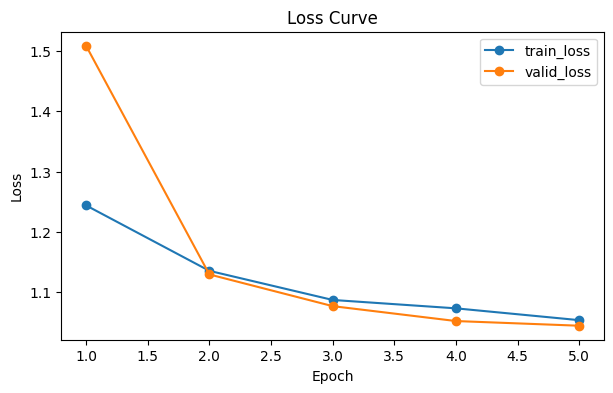

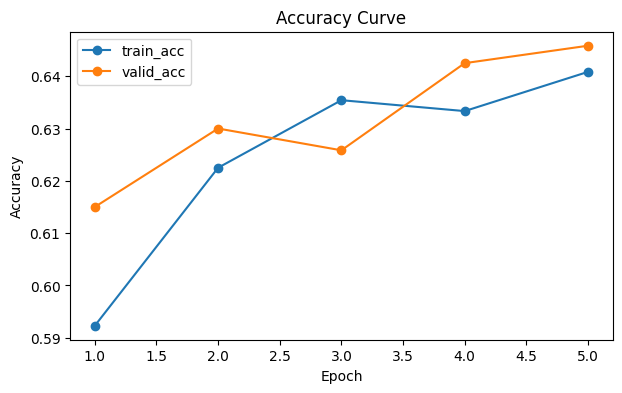

In [9]:
# 8. Learning Curve 분석
#    - train/validation loss와 accuracy 변화를 시각화하여 학습 안정성 및 과적합 여부 확인

plt.figure(figsize=(7, 4))
plt.plot(history_df['epoch'], history_df['train_loss'], marker='o', label='train_loss')
plt.plot(history_df['epoch'], history_df['valid_loss'], marker='o', label='valid_loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history_df['epoch'], history_df['train_acc'], marker='o', label='train_acc')
plt.plot(history_df['epoch'], history_df['valid_acc'], marker='o', label='valid_acc')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## 9. Confusion Matrix 및 Classification Report

과제 요구사항에 맞게 모델의 validation 성능을 Accuracy, Macro F1, Weighted F1로 확인합니다.  
또한 Confusion Matrix와 Classification Report를 통해 어떤 클래스에서 오분류가 많이 발생하는지 분석합니다.



Confusion Matrix
[[  0  37   0  18   6]
 [  0  46   0  58  19]
 [  0   5   0 123   6]
 [  0  21   0 710   7]
 [  0  37   0  88  19]]
Validation Accuracy: 0.6458
Macro F1: 0.2699
Weighted F1: 0.5611


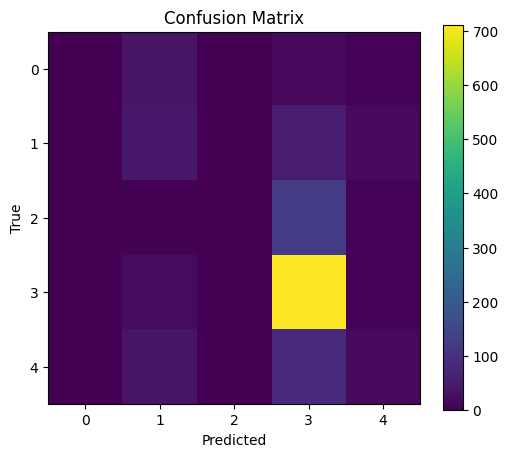

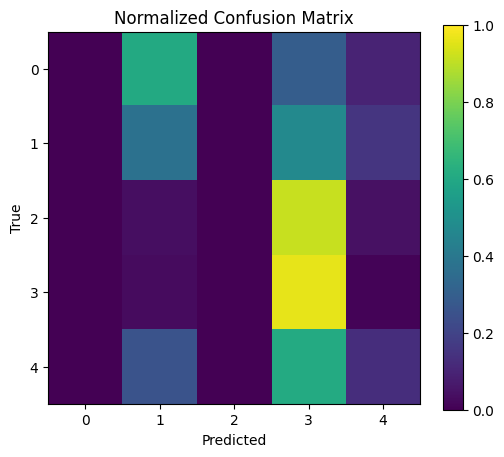

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,precision,recall,f1-score,support
0,0.000000,0.000000,0.000000,61.000000
1,0.315068,0.373984,0.342007,123.000000
2,0.000000,0.000000,0.000000,134.000000
3,0.712136,0.962060,0.818444,738.000000
4,0.333333,0.131944,0.189055,144.000000
accuracy,0.645833,0.645833,0.645833,0.645833
macro avg,0.272108,0.293598,0.269901,1200.000000
weighted avg,0.510258,0.645833,0.561085,1200.000000


              precision    recall  f1-score   support

           0       0.00      0.00      0.00        61
           1       0.32      0.37      0.34       123
           2       0.00      0.00      0.00       134
           3       0.71      0.96      0.82       738
           4       0.33      0.13      0.19       144

    accuracy                           0.65      1200
   macro avg       0.27      0.29      0.27      1200
weighted avg       0.51      0.65      0.56      1200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [10]:
# 9. Confusion Matrix 및 Classification Report
#    - validation 예측 결과를 바탕으로 클래스별 성능과 혼동 패턴 분석

cm = confusion_matrix(valid_labels, valid_preds)
print('Confusion Matrix')
print(cm)

valid_accuracy = accuracy_score(valid_labels, valid_preds)
macro_f1 = f1_score(valid_labels, valid_preds, average='macro')
weighted_f1 = f1_score(valid_labels, valid_preds, average='weighted')

print(f'Validation Accuracy: {valid_accuracy:.4f}')
print(f'Macro F1: {macro_f1:.4f}')
print(f'Weighted F1: {weighted_f1:.4f}')

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.colorbar()
plt.xticks(range(NUM_CLASSES))
plt.yticks(range(NUM_CLASSES))
plt.show()

# 클래스별 개수 차이를 고려하여 normalized confusion matrix도 함께 확인합니다.
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))
plt.imshow(cm_norm, vmin=0, vmax=1)
plt.title('Normalized Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.colorbar()
plt.xticks(range(NUM_CLASSES))
plt.yticks(range(NUM_CLASSES))
plt.show()

report_dict = classification_report(valid_labels, valid_preds, output_dict=True)
report_df = pd.DataFrame(report_dict).T
display(report_df)

print(classification_report(valid_labels, valid_preds))


## 10. 오분류 이미지 예시 분석

Confusion Matrix만으로는 모델이 어떤 시각적 패턴에서 실패했는지 파악하기 어렵습니다.  
따라서 실제로 틀린 validation 이미지를 일부 확인하여 오분류 경향을 분석합니다.



Number of wrong predictions: 425
Wrong prediction ratio: 0.3541666666666667


,true,pred,true_name,pred_name,count
6,2,3,Cassava Green Mottle (CGM),Cassava Mosaic Disease (CMD),123
11,4,3,Healthy,Cassava Mosaic Disease (CMD),88
3,1,3,Cassava Brown Streak Disease (CBSD),Cassava Mosaic Disease (CMD),58
0,0,1,Cassava Bacterial Blight (CBB),Cassava Brown Streak Disease (CBSD),37
10,4,1,Healthy,Cassava Brown Streak Disease (CBSD),37
8,3,1,Cassava Mosaic Disease (CMD),Cassava Brown Streak Disease (CBSD),21
4,1,4,Cassava Brown Streak Disease (CBSD),Healthy,19
1,0,3,Cassava Bacterial Blight (CBB),Cassava Mosaic Disease (CMD),18
9,3,4,Cassava Mosaic Disease (CMD),Healthy,7
2,0,4,Cassava Bacterial Blight (CBB),Healthy,6


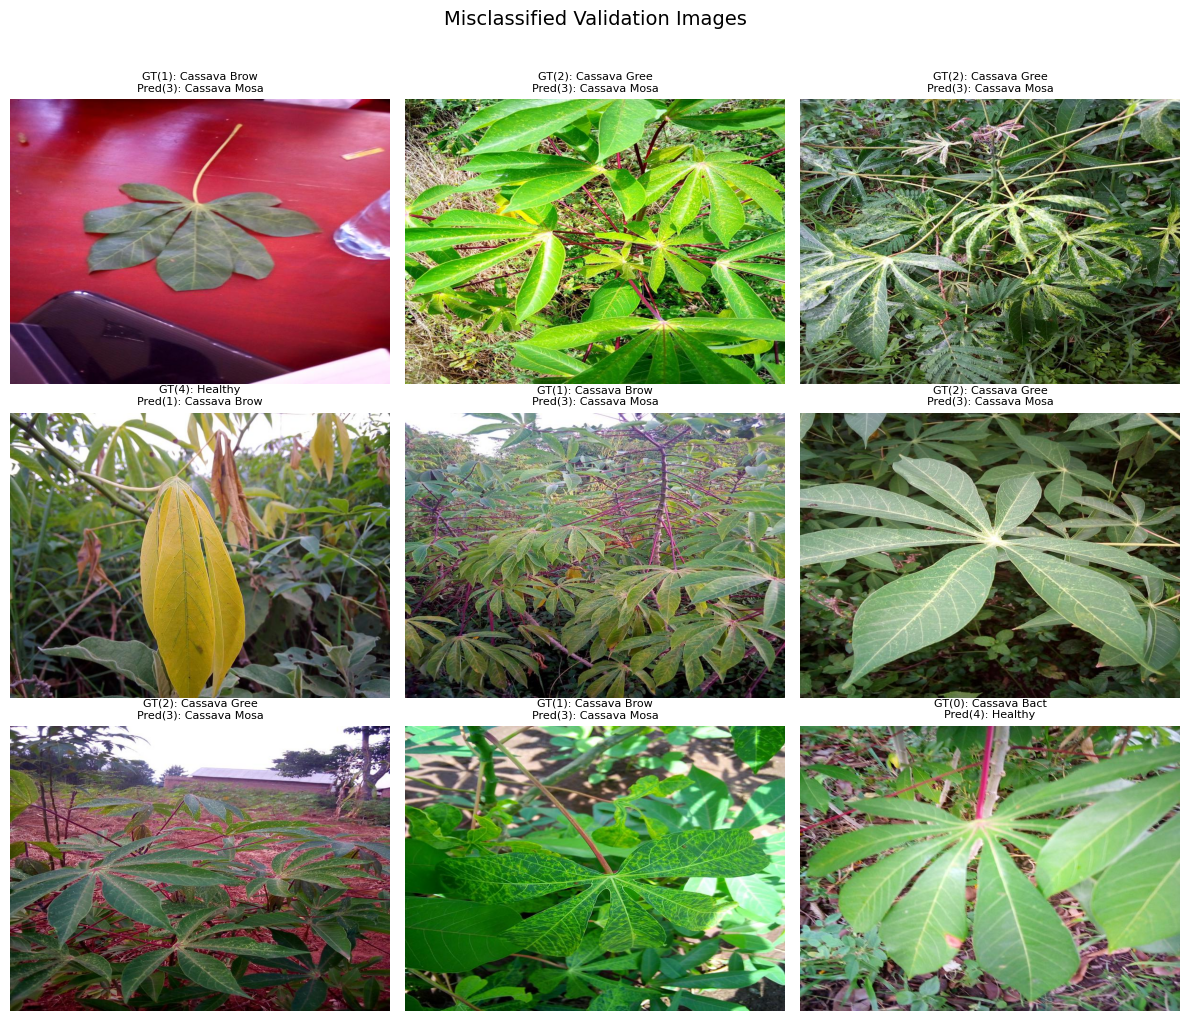

In [11]:
# 10. 오분류 이미지 예시 분석
#    - 실제 label과 예측 label이 다른 validation 이미지를 확인하고 오분류 유형 분석

wrong_indices = np.where(valid_labels != valid_preds)[0]

print('Number of wrong predictions:', len(wrong_indices))
print('Wrong prediction ratio:', len(wrong_indices) / len(valid_labels))

wrong_df = pd.DataFrame({
    'true': valid_labels[wrong_indices],
    'pred': valid_preds[wrong_indices]
})

if len(wrong_df) > 0:
    wrong_df['true_name'] = wrong_df['true'].map(lambda x: label_map.get(str(x), str(x)))
    wrong_df['pred_name'] = wrong_df['pred'].map(lambda x: label_map.get(str(x), str(x)))

    display(
        wrong_df.groupby(['true', 'pred', 'true_name', 'pred_name'])
        .size()
        .reset_index(name='count')
        .sort_values('count', ascending=False)
        .head(10)
    )

n_show = min(9, len(wrong_indices))

if n_show > 0:
    plt.figure(figsize=(12, 10))

    for i, idx in enumerate(wrong_indices[:n_show]):
        row = valid_split.reset_index(drop=True).iloc[idx]
        img = Image.open(TRAIN_IMG_DIR / row['image_id']).convert('RGB')

        true_label = int(valid_labels[idx])
        pred_label = int(valid_preds[idx])

        true_name = label_map.get(str(true_label), str(true_label))
        pred_name = label_map.get(str(pred_label), str(pred_label))

        plt.subplot(3, 3, i + 1)
        plt.imshow(img)
        plt.axis('off')

        plt.title(
            f"GT({true_label}): {true_name[:12]}\n"
            f"Pred({pred_label}): {pred_name[:12]}",
            fontsize=8
        )

    plt.suptitle('Misclassified Validation Images', y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

else:
    print('No wrong predictions found in shown validation set.')


## 11. Test Prediction 및 Submission 생성

학습된 best model을 이용하여 test image에 대한 예측을 수행합니다.  
추가로 original prediction과 horizontal flip TTA prediction을 비교하고, validation 성능이 더 좋은 방식을 기준으로 최종 `submission.csv`를 생성합니다.



In [12]:
# 11. Test Prediction 및 Submission 생성
#    - test image에 대한 예측 결과를 생성하고 Kaggle 제출용 submission.csv 저장

def predict_loader(model, loader, device):
    model.eval()
    image_ids = []
    probs_list = []

    softmax = nn.Softmax(dim=1)

    with torch.no_grad():
        for images, ids in loader:
            images = images.to(device)
            outputs = model(images)
            probs = softmax(outputs).cpu().numpy()

            image_ids.extend(list(ids))
            probs_list.append(probs)

    return image_ids, np.vstack(probs_list)


# Validation TTA 성능을 확인합니다. original prediction과 horizontal flip prediction을 평균합니다.
valid_dataset_tta = CassavaDataset(valid_split, TRAIN_IMG_DIR, transform=tta_transform, is_test=False)
valid_loader_tta = DataLoader(
    valid_dataset_tta,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

def predict_valid_probs(model, loader, device):
    model.eval()
    probs_list = []
    labels_list = []
    softmax = nn.Softmax(dim=1)

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs_list.append(softmax(outputs).cpu().numpy())
            labels_list.extend(labels.numpy())

    return np.vstack(probs_list), np.array(labels_list)

valid_probs_orig, labels_check = predict_valid_probs(model, valid_loader, DEVICE)
valid_probs_flip, _ = predict_valid_probs(model, valid_loader_tta, DEVICE)
valid_probs_tta = (valid_probs_orig + valid_probs_flip) / 2

preds_orig = valid_probs_orig.argmax(axis=1)
preds_tta = valid_probs_tta.argmax(axis=1)

orig_acc = accuracy_score(labels_check, preds_orig)
tta_acc = accuracy_score(labels_check, preds_tta)
orig_f1 = f1_score(labels_check, preds_orig, average='macro')
tta_f1 = f1_score(labels_check, preds_tta, average='macro')

tta_result_df = pd.DataFrame([
    {'method': 'Original', 'accuracy': orig_acc, 'macro_f1': orig_f1},
    {'method': 'Horizontal Flip TTA', 'accuracy': tta_acc, 'macro_f1': tta_f1},
])
display(tta_result_df)

use_tta = tta_acc >= orig_acc
print('Use TTA for submission:', use_tta)

# Test prediction을 수행합니다.
test_dataset = CassavaDataset(
    sample_submission,
    TEST_IMG_DIR,
    transform=valid_transform,
    is_test=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_image_ids, test_probs = predict_loader(model, test_loader, DEVICE)

if use_tta:
    test_dataset_tta = CassavaDataset(
        sample_submission,
        TEST_IMG_DIR,
        transform=tta_transform,
        is_test=True
    )
    test_loader_tta = DataLoader(
        test_dataset_tta,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    _, test_probs_flip = predict_loader(model, test_loader_tta, DEVICE)
    test_probs = (test_probs + test_probs_flip) / 2

test_preds = test_probs.argmax(axis=1)

submission = pd.DataFrame({
    'image_id': test_image_ids,
    'label': test_preds
})

submission.to_csv(OUTPUT_PATH, index=False)

print('Saved:', OUTPUT_PATH)
display(submission.head())
print(submission.shape)
print(submission['label'].value_counts().sort_index())


,method,accuracy,macro_f1
0,Original,0.645833,0.269901
1,Horizontal Flip TTA,0.644167,0.268060


Use TTA for submission: False
Saved: /kaggle/working/submission.csv


,image_id,label
0,2216849948.jpg,3


(1, 2)
label
3    1
Name: count, dtype: int64


## 12. 정리 및 결론

본 노트북에서는 Cassava Leaf Disease Classification 대회를 대상으로 카사바 잎 이미지 분류 모델을 구축하였습니다.  
먼저 클래스 분포를 확인하여 데이터 불균형 문제를 살펴보았고, EfficientNet-B0 기반 모델에 data augmentation과 label smoothing을 적용하여 성능 개선을 시도하였습니다.

수행한 주요 내용은 다음과 같습니다.

- Cassava Leaf Disease 이미지 분류 문제 수행
- 클래스 불균형 확인
- Kaggle 인터넷 OFF 환경을 고려하여 pretrained weight 없이 EfficientNet-B0 학습
- V1 기반 안전 개선 적용
  - 이미지 크기 증가
  - epoch 증가
  - 약한 label smoothing 적용
  - CosineAnnealingLR scheduler 적용
  - gradient clipping 적용
  - best validation accuracy 기준 모델 저장
  - horizontal flip TTA 성능 비교
- Validation Accuracy, Macro F1, Weighted F1 확인
- Confusion Matrix 및 Normalized Confusion Matrix 분석
- Classification Report 확인
- 오분류 조합 및 오분류 이미지 분석
- Kaggle 제출용 `submission.csv` 생성

V3 실험에서는 강한 augmentation, class weight, 복잡한 TTA 등을 동시에 적용하였을 때 Kaggle score가 하락하였습니다.  
따라서 본 실험에서는 V1에서 비교적 안정적으로 동작한 구조를 유지하면서, 성능을 크게 흔들 가능성이 낮은 개선만 적용하였습니다.  

